# Machine Learning

### Criar um modelo de máquina que possa prever se um pedido de cartão de crédito será aprovado

Análise de crédito consiste em avaliar se determinado cliente tem as condições necessárias para cumprir determinado compromisso financeiro. A partir dos seus dados, instituições financerias recusam ou aprovam cartões de crédito. Para garantir a real capacidade de pagamento, são avaliados, além dos dados pessoais, também, dados residenciais, renda e outros dados creditícios.

Considerando, para este exercício de predição, usar tecnologias que ajudam na concessão de crédito, cito as ferramentas das quais são necessárias para tomada de decisão mais acertiva:
1. Big Data 
   - Mantendo os dados do forma bruta, são mantidos em locais de armazenamento e capaz de armazenar diferentes formatos  e ficam exportos 
2. Machine Learning
   - Automatiza a análise de dados por meio de modelos analíticos
3. Bussiness Intelligence (BI)
   - Garante agilidade e permite observar riscos na operação. Seus dados são tratados na origem
   
### Neste artigo, vamos compor um modelo automático de predição de aprovação de cartão de crédito usando técnicas de Machine Learning.
Com intuito de demonstrar técnicas analíticas, usarei este conjunto de dados de aprovação de crédito do [Repositório de aprendizado de Máquinas UCI](http://archive.ics.uci.edu/ml/datasets/credit+approval). Uma coleção de solicitações de crédito e as decisões de aprovação. 

As técnicas incluem visualização de dados, regras de associação, regressão logística e árvore de decisão seguindo a ordem estabelecida:
1. Visualização de dados para entender os dados;
2. Transformar os dadospar sua adequação;
3. Desenvolver perguntas de pesquisa sobre os dados;
4. Applicar o modelo para melhor responder as questões da pesquisa.

### Estrutura dos dados:
| Características do conjunto de dados| Multivariável |
|---|---|
| Número de Instâncias | 690 |
| Características do atributo | Categórico, Inteiro, Real |
| Número de atributos | 15 |
| Valores ausentes? | sim |


Vamos lá?

## Load da base de dados

In [1]:
# Import Pandas
import pandas as pd

# Import extension for jupyter notebook to beatify python code automatically using Black
%load_ext nb_black

# Load dataset
dataset = pd.read_csv("crx.data", header=None)

# Load
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

### Análise exploratória e transformação dos dados

O primeiro passo de qualquer análise é obter o conjunto de dados.

In [2]:
# inspect data
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


<IPython.core.display.Javascript object>

#### Informações dos tipos de dados
Uma rápida observação, vimos que os dados foram convertidos em símbolos sem sentido para proteger a confidencialidade dos dados.

Poderíamos considerar quais são recursos mais prováveis de um conjunto de dados, mas este [blog](http://rstudio-pubs-static.s3.amazonaws.com/73039_9946de135c0a49daa7a0a9eda4a67a72.html) nos dá uma visão dos recursos possíveis em um aplicativo de cartão de crédito: Gender, Age, Debt, Married, BankCustomer, EducationLevel, Ethnicity, YearsEmployed, PriorDefault, Employed, CreditScore, DriversLicense, Citizen, ZipCode, Incomee finalmente o ApprovalStatus. 

Isso nos dá um bom ponto de partida e podemos mapear esses recursos em relação às colunas na saída.

Usamos a função info() para compreender os tipos de dados no conjunto de dados. Esta função mostra suas colunas, tipos a considerar, quantidade de registros, nomes dos atributos...

In [3]:
# inspect data
dataset.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


<IPython.core.display.Javascript object>

Considerando que estamos praticando e que não estamos usando os dados para desenvolver critérios reais. Para facilitar o trabalho com o conjunto de dados, renomeei as colunas com base no tipo de dados, considerando a interpretação do [Ryan Kuhn](http://rstudio-pubs-static.s3.amazonaws.com/73039_9946de135c0a49daa7a0a9eda4a67a72.html) em sua análise.

In [4]:
dataset = dataset.rename(
    columns={
        0: "Gênero",
        1: "Tempo do Pedido",
        2: "Dívida",
        3: "Estado Civil",
        4: "Cliente do Banco",
        5: "Escolaridade",
        6: "Etnia",
        7: "Anos de Serviço",
        8: "Padrão anterior",
        9: "Empregado",
        10: "Pontos de Crédito",
        11: "CNH",
        12: "Cidadão",
        13: "Código Postal",
        14: "Renda",
        15: "Situação",
    }
)

<IPython.core.display.Javascript object>

In [5]:
dataset.tail(20)

,Gênero,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Etnia,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Cidadão,Código Postal,Renda,Situação
670,b,47.17,5.835,u,g,w,v,5.500,f,f,0,f,g,00465,150,-
671,b,25.83,12.835,u,g,cc,v,0.500,f,f,0,f,g,00000,2,-
672,a,50.25,0.835,u,g,aa,v,0.500,f,f,0,t,g,00240,117,-
673,?,29.50,2.000,y,p,e,h,2.000,f,f,0,f,g,00256,17,-
674,a,37.33,2.500,u,g,i,h,0.210,f,f,0,f,g,00260,246,-
675,a,41.58,1.040,u,g,aa,v,0.665,f,f,0,f,g,00240,237,-
676,a,30.58,10.665,u,g,q,h,0.085,f,t,12,t,g,00129,3,-
677,b,19.42,7.250,u,g,m,v,0.040,f,t,1,f,g,00100,1,-
678,a,17.92,10.210,u,g,ff,ff,0.000,f,f,0,f,g,00000,50,-
679,a,20.08,1.250,u,g,c,v,0.000,f,f,0,f,g,00000,0,-


<IPython.core.display.Javascript object>

Com os nomes das colunas mais adequada, detectei alguns dados ausentes rotulados com '?' (vide linha 673).
Com os dados que estão faltando, determinar a melhor maneira de abordá-los. Podemos remover, zerá-los ou estimar um valor. Vamos modificar os valores ausentes para NaN. Mais adiante vai nos ajudar no tratamento do valor faltante.

In [6]:
# Import numpy
import numpy as np

# Replace the "?"s with NaN
dataset = dataset.replace("?", np.nan)

# Inspect the missing values again
dataset.tail(20)

,Gênero,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Etnia,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Cidadão,Código Postal,Renda,Situação
670,b,47.17,5.835,u,g,w,v,5.500,f,f,0,f,g,00465,150,-
671,b,25.83,12.835,u,g,cc,v,0.500,f,f,0,f,g,00000,2,-
672,a,50.25,0.835,u,g,aa,v,0.500,f,f,0,t,g,00240,117,-
673,NaN,29.50,2.000,y,p,e,h,2.000,f,f,0,f,g,00256,17,-
674,a,37.33,2.500,u,g,i,h,0.210,f,f,0,f,g,00260,246,-
675,a,41.58,1.040,u,g,aa,v,0.665,f,f,0,f,g,00240,237,-
676,a,30.58,10.665,u,g,q,h,0.085,f,t,12,t,g,00129,3,-
677,b,19.42,7.250,u,g,m,v,0.040,f,t,1,f,g,00100,1,-
678,a,17.92,10.210,u,g,ff,ff,0.000,f,f,0,f,g,00000,50,-
679,a,20.08,1.250,u,g,c,v,0.000,f,f,0,f,g,00000,0,-


<IPython.core.display.Javascript object>

In [7]:
dataset.isnull().sum()

Gênero               12
Tempo do Pedido      12
Dívida                0
Estado Civil          6
Cliente do Banco      6
Escolaridade          9
Etnia                 9
Anos de Serviço       0
Padrão anterior       0
Empregado             0
Pontos de Crédito     0
CNH                   0
Cidadão               0
Código Postal        13
Renda                 0
Situação              0
dtype: int64

<IPython.core.display.Javascript object>

### Manipulando os valores ausentes
Descobrimos alguns problemas que podem afetar nossa análise do conjunto de dados.
 - dados numéricos e não-numéricos;
 - Colunas que contém valores numéricos dos tipos float64, int64, para os demais os valores são não-numéricos;
 - intervalos de 0 a 28, de 0 a 67, capturados a partir de sua descrição com estatística úteis( mean, max e min) nas colunas.

In [8]:
# Impute the missing values with mean imputation
# dataset.fillna("NaN", inplace=True)

<IPython.core.display.Javascript object>

In [9]:
dataset.dropna(inplace=True)

<IPython.core.display.Javascript object>

In [10]:
# I changed the column type "Lost Time" to float.
dataset["Tempo do Pedido"] = dataset["Tempo do Pedido"].astype("float64")

<IPython.core.display.Javascript object>

### Descrição do Dataset
Vamos aprender mais um pouco sobre o dataset usando a função describe() e trazer um sumário estatístico. Com dados como mín., média e mediana

In [11]:
dataset.describe()

,Tempo do Pedido,Dívida,Anos de Serviço,Pontos de Crédito,Renda
count,653.000000,653.000000,653.000000,653.000000,653.000000
mean,31.503813,4.829533,2.244296,2.502297,1013.761103
std,11.838267,5.027077,3.371120,4.968497,5253.278504
min,13.750000,0.000000,0.000000,0.000000,0.000000
25%,22.580000,1.040000,0.165000,0.000000,0.000000
50%,28.420000,2.835000,1.000000,0.000000,5.000000
75%,38.250000,7.500000,2.625000,3.000000,400.000000
max,76.750000,28.000000,28.500000,67.000000,100000.000000


<IPython.core.display.Javascript object>

## Correlação de dependências
A tabela abaixo mostra uma correlação entre variáveis. Acompanhando os dados por linhas, vimos uma correlação forte entre o tempo do pedido e o tempo do trabalho empregado, seguido pela dívida.

In [12]:
dataset.corr()

,Tempo do Pedido,Dívida,Anos de Serviço,Pontos de Crédito,Renda
Tempo do Pedido,1.000000,0.217681,0.417647,0.198153,0.029078
Dívida,0.217681,1.000000,0.300600,0.269834,0.119754
Anos de Serviço,0.417647,0.300600,1.000000,0.327325,0.052159
Pontos de Crédito,0.198153,0.269834,0.327325,1.000000,0.058408
Renda,0.029078,0.119754,0.052159,0.058408,1.000000


<IPython.core.display.Javascript object>

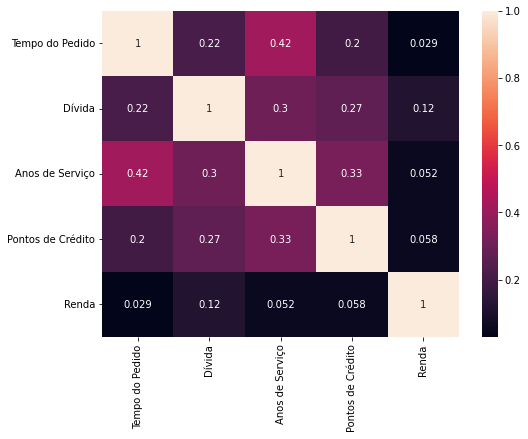

<IPython.core.display.Javascript object>

In [13]:
import seaborn as sns

corr_df = dataset.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True)
plt.show()

## Correlações a considerar:
- Anos de Serviço com Tempo de pedido
- Anos de serviço com Dívida
- Crédito com anos de serviço

## Feature Engineering
Avaliar quais variaveis são importantes para construção do modelo, podem surgir novas.

- Remover colunas Etnia e Gênero 
    - Por considerar que no Brasil, este dados não são relevantes (discutir sobre o assunto)
- Remover Cidadão 
    - (dados insuficientes em todas categorias)

In [14]:
dataset["Situação"].value_counts()

-    357
+    296
Name: Situação, dtype: int64

<IPython.core.display.Javascript object>

In [15]:
dataset["Cidadão"].value_counts()

g    598
s     53
p      2
Name: Cidadão, dtype: int64

<IPython.core.display.Javascript object>

In [16]:
dataset["Padrão anterior"].value_counts()

t    349
f    304
Name: Padrão anterior, dtype: int64

<IPython.core.display.Javascript object>

In [17]:
newDataset = dataset.drop(columns=["Etnia", "Gênero", "Cidadão", "Código Postal"])
newDataset.head()

,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Renda,Situação
0,30.83,0.000,u,g,w,1.25,t,t,1,f,0,+
1,58.67,4.460,u,g,q,3.04,t,t,6,f,560,+
2,24.50,0.500,u,g,q,1.50,t,f,0,f,824,+
3,27.83,1.540,u,g,w,3.75,t,t,5,t,3,+
4,20.17,5.625,u,g,w,1.71,t,f,0,f,0,+


<IPython.core.display.Javascript object>

## Feature Engineering (variáveis)
- colocar tudo em numérico
- depois fazer uma nova correlação
- Categorias ou inteiros

- Criar variável capacidade_de_endividamento (Renda/Dívida)
- aparenta ser que a renda é anual

In [18]:
newDataset.head()

,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Renda,Situação
0,30.83,0.000,u,g,w,1.25,t,t,1,f,0,+
1,58.67,4.460,u,g,q,3.04,t,t,6,f,560,+
2,24.50,0.500,u,g,q,1.50,t,f,0,f,824,+
3,27.83,1.540,u,g,w,3.75,t,t,5,t,3,+
4,20.17,5.625,u,g,w,1.71,t,f,0,f,0,+


<IPython.core.display.Javascript object>

In [19]:
newDataset["Escolaridade"].value_counts()

c     133
q      75
w      63
i      55
aa     52
ff     50
k      48
cc     40
m      38
x      36
d      26
e      24
j      10
r       3
Name: Escolaridade, dtype: int64

<IPython.core.display.Javascript object>

In [20]:
def input_enconding(series):
    series_list = list(series.value_counts().index)
    series_dict = dict(zip(series_list, [i for i in range(len(series_list))]))
    return series_dict

<IPython.core.display.Javascript object>

In [21]:
input_enconding(newDataset["Escolaridade"])

{'c': 0,
 'q': 1,
 'w': 2,
 'i': 3,
 'aa': 4,
 'ff': 5,
 'k': 6,
 'cc': 7,
 'm': 8,
 'x': 9,
 'd': 10,
 'e': 11,
 'j': 12,
 'r': 13}

<IPython.core.display.Javascript object>

In [22]:
replace_list = [
    "Situação",
    "Estado Civil",
    "Cliente do Banco",
    "Escolaridade",
    "Padrão anterior",
    "Empregado",
    "CNH",
]
for el in replace_list:
    newDataset = newDataset.replace(
        {
            el: input_enconding(newDataset[el]),
        }
    )
newDataset.head()

,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Renda,Situação
0,30.83,0.000,0,0,2,1.25,0,1,1,0,0,1
1,58.67,4.460,0,0,1,3.04,0,1,6,0,560,1
2,24.50,0.500,0,0,1,1.50,0,0,0,0,824,1
3,27.83,1.540,0,0,2,3.75,0,1,5,1,3,1
4,20.17,5.625,0,0,2,1.71,0,0,0,0,0,1


<IPython.core.display.Javascript object>

In [23]:
newDataset.loc[(newDataset['Renda'] == 0) & (newDataset['Dívida'] > 0)]


,Tempo do Pedido,Dívida,Estado Civil,Cliente do Banco,Escolaridade,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Renda,Situação
4,20.17,5.625,0,0,2,1.710,0,0,0,0,0,1
5,32.08,4.000,0,0,8,2.500,0,0,0,1,0,1
10,22.08,0.830,0,0,0,2.165,1,0,0,1,0,1
12,38.25,6.000,0,0,6,1.000,0,0,0,1,0,1
14,45.83,10.500,0,0,1,5.000,0,1,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
668,30.33,0.500,0,0,10,0.085,1,0,0,1,0,0
679,20.08,1.250,0,0,0,0.000,1,0,0,0,0,0
684,40.58,3.290,0,0,8,3.500,1,0,0,1,0,0
685,21.08,10.085,1,1,11,1.250,1,0,0,0,0,0


<IPython.core.display.Javascript object>

In [24]:
!pip install phik

<IPython.core.display.Javascript object>

In [25]:
import phik
from phik import resources, report

<IPython.core.display.Javascript object>

interval columns not set, guessing: ['Tempo do Pedido', 'Dívida', 'Estado Civil', 'Cliente do Banco', 'Escolaridade', 'Anos de Serviço', 'Padrão anterior', 'Empregado', 'Pontos de Crédito', 'CNH', 'Renda']


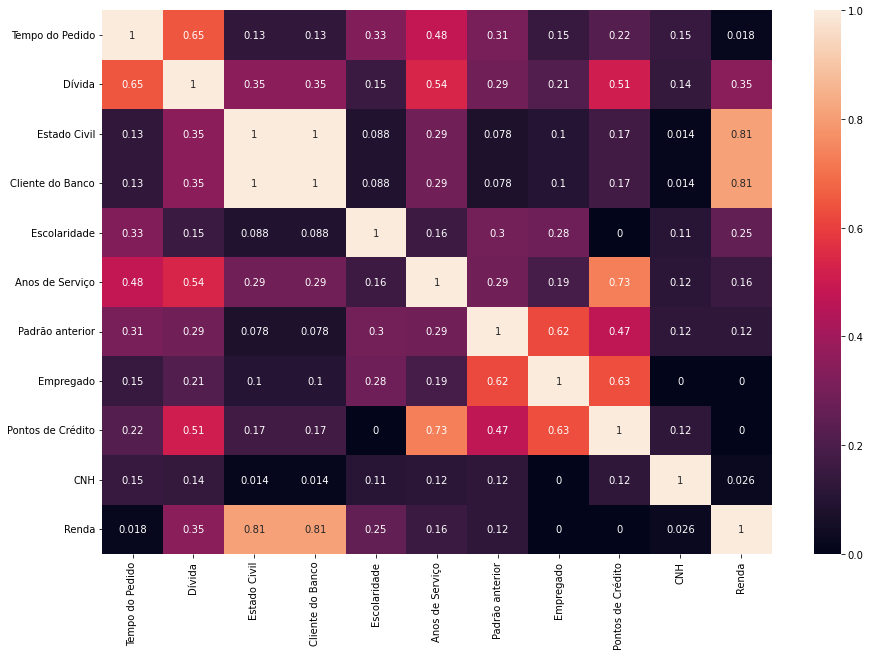

<IPython.core.display.Javascript object>

In [26]:
import seaborn as sns

corr_df = newDataset.drop("Situação", axis=1).phik_matrix()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_df, annot=True)
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

<IPython.core.display.Javascript object>

In [39]:
X = newDataset.drop(["Situação", "Estado Civil"], axis=1)
Y = newDataset["Situação"]
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=0
)

clf = LogisticRegression(random_state=0).fit(X_train, y_train)


C:\Users\dgeis\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<IPython.core.display.Javascript object>

In [51]:
X_test[clf.predict_proba(X_test)[:, 1] > 0.8]

,Tempo do Pedido,Dívida,Cliente do Banco,Escolaridade,Anos de Serviço,Padrão anterior,Empregado,Pontos de Crédito,CNH,Renda
564,42.17,5.040,0,1,12.750,0,0,0,1,0
14,45.83,10.500,0,1,5.000,0,1,7,1,0
132,47.42,8.000,0,11,6.500,0,1,6,0,51100
558,51.42,0.040,0,9,0.040,0,0,0,0,3000
180,47.67,0.290,0,0,15.000,0,1,20,0,15000
553,38.58,3.335,0,2,4.000,0,1,14,0,1344
212,60.08,14.500,0,5,18.000,0,1,15,1,1000
496,25.00,0.875,0,9,1.040,0,0,0,1,5860
199,22.58,10.040,0,9,0.040,0,1,9,0,396
213,23.08,11.500,0,3,3.500,0,1,9,0,742


<IPython.core.display.Javascript object>

In [36]:
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1],
      dtype=int64)

<IPython.core.display.Javascript object>

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.84      0.88       109
           1       0.82      0.90      0.86        87

    accuracy                           0.87       196
   macro avg       0.87      0.87      0.87       196
weighted avg       0.87      0.87      0.87       196



<IPython.core.display.Javascript object>

In [64]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=0).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       109
           1       0.88      0.90      0.89        87

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



<IPython.core.display.Javascript object>

In [65]:
clf = RandomForestClassifier(random_state=0, criterion="entropy").fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       109
           1       0.88      0.91      0.89        87

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



<IPython.core.display.Javascript object>

In [73]:
clf = RandomForestClassifier(random_state=0, criterion="entropy", n_estimators=9).fit(
    X_train, y_train
)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       109
           1       0.88      0.93      0.91        87

    accuracy                           0.91       196
   macro avg       0.91      0.92      0.91       196
weighted avg       0.91      0.91      0.91       196



<IPython.core.display.Javascript object>

In [79]:
from sklearn.model_selection import GridSearchCV

<IPython.core.display.Javascript object>

In [88]:
parameters = {
    "criterion": ["gini", "entropy"],
    "n_estimators": [100, 5, 9, 300, 50],
    "max_depth": [None, 10, 5, 20, 50],
}
estimator = RandomForestClassifier(random_state=0)
clf = GridSearchCV(estimator, parameters, scoring="f1")
clf.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 5, 20, 50],
                         'n_estimators': [100, 5, 9, 300, 50]},
             scoring='f1')

<IPython.core.display.Javascript object>

In [89]:
clf.best_params_

{'criterion': 'entropy', 'max_depth': None, 'n_estimators': 100}

<IPython.core.display.Javascript object>

In [90]:
y_pred = clf.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       109
           1       0.88      0.91      0.89        87

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



<IPython.core.display.Javascript object>